# Supply-Prescript — Predictive Modeling

## Objective

The objective of this phase is to build a machine-learning model that predicts supply-chain delivery risk using operational, supplier, logistics, and disruption-related features.

### Steps
1. Load the cleaned dataset
2. Inspect modeling variables
3. Select the prediction target
4. Check for target leakage
5. Prepare features
6. Encode categorical variables
7. Split training and testing data
8. Train baseline models
9. Evaluate models
10. Select the best model
11. Analyze feature importance
12. Save the final model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
file_path = "../data/processed/supply_chain_cleaned.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (113097, 18)


In [3]:
print("=" * 60)
print("DATASET INFORMATION FOR MODELING")
print("=" * 60)

print("\nShape:", df.shape)

print("\nColumns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

DATASET INFORMATION FOR MODELING

Shape: (113097, 18)

Columns:
1. warehouse_inventory_level
2. handling_equipment_availability
3. order_fulfillment_status
4. weather_condition_severity
5. shipping_costs
6. supplier_reliability_score
7. lead_time_days
8. historical_demand
9. cargo_condition_status
10. route_risk_level
11. customs_clearance_time
12. disruption_likelihood_score
13. delay_probability
14. risk_classification
15. delivery_time_deviation
16. product_id
17. supplier_id
18. supplier_country

Data Types:
warehouse_inventory_level          float64
handling_equipment_availability    float64
order_fulfillment_status           float64
weather_condition_severity         float64
shipping_costs                     float64
supplier_reliability_score         float64
lead_time_days                     float64
historical_demand                  float64
cargo_condition_status             float64
route_risk_level                   float64
customs_clearance_time             float64
disruptio

In [4]:
print("=" * 60)
print("TARGET VARIABLE ANALYSIS")
print("=" * 60)

target_counts = df["risk_classification"].value_counts()
target_percent = df["risk_classification"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})

print(target_summary)

TARGET VARIABLE ANALYSIS
                     Count  Percentage
risk_classification                   
High Risk            84368       74.60
Moderate Risk        17783       15.72
Low Risk             10946        9.68


In [5]:
print("Risk Classification vs Delay Probability")
print(
    df.groupby("risk_classification")["delay_probability"]
      .agg(["min", "max", "mean", "median"])
      .round(4)
)

print("\nRisk Classification vs Delivery Time Deviation")
print(
    df.groupby("risk_classification")["delivery_time_deviation"]
      .agg(["min", "max", "mean", "median"])
      .round(4)
)

Risk Classification vs Delay Probability
                     min  max    mean  median
risk_classification                          
High Risk            0.0  1.0  0.6989  0.8389
Low Risk             0.0  1.0  0.7093  0.8506
Moderate Risk        0.0  1.0  0.6971  0.8431

Risk Classification vs Delivery Time Deviation
                        min   max    mean  median
risk_classification                              
High Risk           -2.0000  10.0  5.1772  6.1222
Low Risk            -1.9998  10.0  5.0990  5.9116
Moderate Risk       -2.0000  10.0  5.1831  6.0091


## 4. Feature Selection

The target variable for the predictive model is `risk_classification`.

Identifier columns such as `product_id` and `supplier_id` are excluded because they primarily identify individual entities rather than representing general operational conditions.

`supplier_country` is retained as a categorical feature because geographic information may contribute to supply-chain risk.

The remaining operational, logistics, supplier, weather, disruption, and delivery variables are used as predictors.

In [6]:
# Define target variable
target = "risk_classification"

# Columns that should not be used as predictive features
drop_columns = [
    "risk_classification",
    "product_id",
    "supplier_id"
]

# Create feature matrix X and target vector y
X = df.drop(columns=drop_columns)
y = df[target]

print("=" * 60)
print("FEATURE SELECTION COMPLETED")
print("=" * 60)

print("\nNumber of Features:", X.shape[1])
print("Number of Records:", X.shape[0])

print("\nSelected Features:")
for i, col in enumerate(X.columns, start=1):
    print(f"{i}. {col}")

print("\nTarget Variable:", target)

FEATURE SELECTION COMPLETED

Number of Features: 15
Number of Records: 113097

Selected Features:
1. warehouse_inventory_level
2. handling_equipment_availability
3. order_fulfillment_status
4. weather_condition_severity
5. shipping_costs
6. supplier_reliability_score
7. lead_time_days
8. historical_demand
9. cargo_condition_status
10. route_risk_level
11. customs_clearance_time
12. disruption_likelihood_score
13. delay_probability
14. delivery_time_deviation
15. supplier_country

Target Variable: risk_classification


In [7]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("=" * 60)
print("FEATURE TYPES")
print("=" * 60)

print("\nNumerical Features:", len(numerical_features))
for col in numerical_features:
    print("-", col)

print("\nCategorical Features:", len(categorical_features))
for col in categorical_features:
    print("-", col)

FEATURE TYPES

Numerical Features: 14
- warehouse_inventory_level
- handling_equipment_availability
- order_fulfillment_status
- weather_condition_severity
- shipping_costs
- supplier_reliability_score
- lead_time_days
- historical_demand
- cargo_condition_status
- route_risk_level
- customs_clearance_time
- disruption_likelihood_score
- delay_probability
- delivery_time_deviation

Categorical Features: 1
- supplier_country


## 5. Train-Test Split

The dataset is divided into 80% training data and 20% testing data.

Stratified sampling is used so that the proportion of High Risk, Moderate Risk, and Low Risk records remains approximately the same in both datasets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining Target Distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Target Distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

TRAIN-TEST SPLIT

X_train: (90477, 15)
X_test : (22620, 15)
y_train: (90477,)
y_test : (22620,)

Training Target Distribution (%):
risk_classification
High Risk        74.60
Moderate Risk    15.72
Low Risk          9.68
Name: proportion, dtype: float64

Testing Target Distribution (%):
risk_classification
High Risk        74.60
Moderate Risk    15.73
Low Risk          9.68
Name: proportion, dtype: float64


In [9]:
# Preprocessing for categorical variables

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [10]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_balanced_accuracy = balanced_accuracy_score(
    y_test,
    baseline_predictions
)

print("=" * 60)
print("BASELINE MODEL")
print("=" * 60)

print(f"\nAccuracy: {baseline_accuracy:.4f}")
print(f"Balanced Accuracy: {baseline_balanced_accuracy:.4f}")

BASELINE MODEL

Accuracy: 0.7460
Balanced Accuracy: 0.3333


## 6. Logistic Regression Model

Logistic Regression is used as the first classification model and serves as an interpretable machine-learning benchmark.

Class weighting is applied because the target classes are imbalanced.

In [11]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("classifier",
         LogisticRegression(
             max_iter=1000,
             class_weight="balanced",
             random_state=42
         ))
    ]
)

print("Training Logistic Regression...")

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression training completed!")

Training Logistic Regression...
Logistic Regression training completed!


C:\Users\Mansi Kurne\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
logistic_predictions = logistic_pipeline.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_balanced_accuracy = balanced_accuracy_score(
    y_test,
    logistic_predictions
)

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"\nAccuracy: {logistic_accuracy:.4f}")
print(f"Balanced Accuracy: {logistic_balanced_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

LOGISTIC REGRESSION RESULTS

Accuracy: 0.8822
Balanced Accuracy: 0.8544

Classification Report:
               precision    recall  f1-score   support

    High Risk       0.96      0.91      0.93     16874
     Low Risk       0.90      0.92      0.91      2189
Moderate Risk       0.60      0.74      0.66      3557

     accuracy                           0.88     22620
    macro avg       0.82      0.85      0.83     22620
 weighted avg       0.89      0.88      0.89     22620



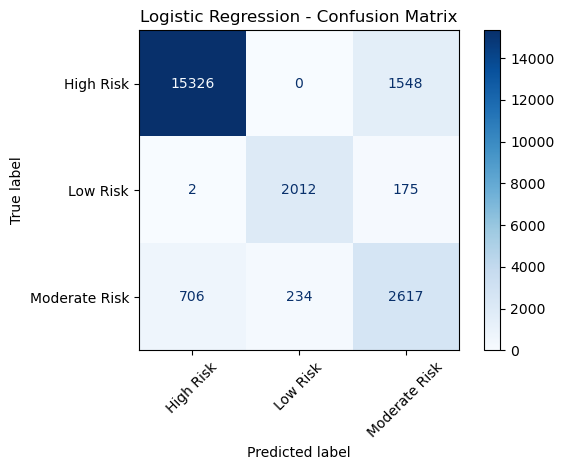

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

## 7. Random Forest Model

Random Forest is used as the second classification model.

Unlike Logistic Regression, Random Forest can capture nonlinear relationships and complex interactions between supply-chain variables.

Class weighting is used to reduce the effect of the imbalanced target classes.

In [14]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("classifier",
         RandomForestClassifier(
             n_estimators=200,
             max_depth=20,
             min_samples_split=5,
             min_samples_leaf=2,
             class_weight="balanced",
             random_state=42,
             n_jobs=-1
         ))
    ]
)

print("Training Random Forest...")

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [15]:
random_forest_predictions = random_forest_pipeline.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

rf_balanced_accuracy = balanced_accuracy_score(
    y_test,
    random_forest_predictions
)

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"\nAccuracy: {rf_accuracy:.4f}")
print(f"Balanced Accuracy: {rf_balanced_accuracy:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        random_forest_predictions
    )
)

RANDOM FOREST RESULTS

Accuracy: 1.0000
Balanced Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

    High Risk       1.00      1.00      1.00     16874
     Low Risk       1.00      1.00      1.00      2189
Moderate Risk       1.00      1.00      1.00      3557

     accuracy                           1.00     22620
    macro avg       1.00      1.00      1.00     22620
 weighted avg       1.00      1.00      1.00     22620



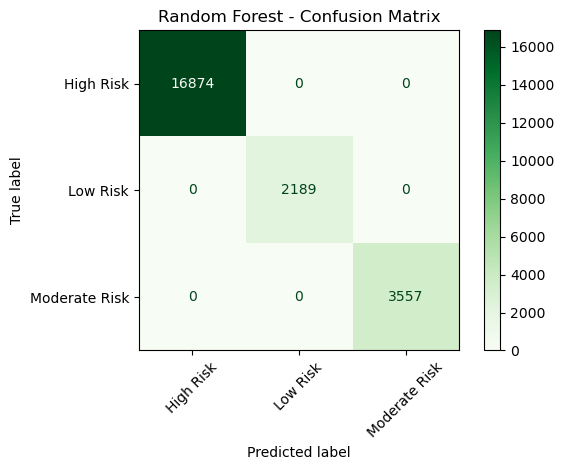

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_predictions,
    cmap="Greens",
    xticks_rotation=45
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. Model Comparison

The Logistic Regression and Random Forest models are compared using accuracy, balanced accuracy, precision, recall, and F1-score.

Because the dataset contains an imbalanced target variable, balanced accuracy and macro F1-score are especially important for selecting the final model.

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, random_forest_predictions)
    ],

    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, logistic_predictions),
        balanced_accuracy_score(y_test, random_forest_predictions)
    ],

    "Precision (Macro)": [
        precision_score(
            y_test,
            logistic_predictions,
            average="macro"
        ),

        precision_score(
            y_test,
            random_forest_predictions,
            average="macro"
        )
    ],

    "Recall (Macro)": [
        recall_score(
            y_test,
            logistic_predictions,
            average="macro"
        ),

        recall_score(
            y_test,
            random_forest_predictions,
            average="macro"
        )
    ],

    "F1 Score (Macro)": [
        f1_score(
            y_test,
            logistic_predictions,
            average="macro"
        ),

        f1_score(
            y_test,
            random_forest_predictions,
            average="macro"
        )
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Balanced Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
0,Logistic Regression,0.8822,0.8544,0.8182,0.8544,0.8339
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000


## 9. Target Leakage Investigation

The Random Forest model achieved 100% classification accuracy. Although this appears excellent, perfect performance may indicate target leakage.

Target leakage occurs when the input features contain information that directly or indirectly reveals the target variable.

Therefore, the relationship between the target variable and potentially derived features is investigated before selecting the final predictive model.

In [19]:
# Check numerical feature relationships with each risk class

suspected_features = [
    "delay_probability",
    "delivery_time_deviation",
    "disruption_likelihood_score",
    "route_risk_level",
    "supplier_reliability_score"
]

for feature in suspected_features:
    print("\n" + "=" * 70)
    print(f"FEATURE: {feature}")
    print("=" * 70)

    print(
        df.groupby("risk_classification")[feature]
          .agg(["min", "max", "mean", "median", "std"])
          .round(4)
    )


FEATURE: delay_probability
                     min  max    mean  median     std
risk_classification                                  
High Risk            0.0  1.0  0.6989  0.8389  0.3241
Low Risk             0.0  1.0  0.7093  0.8506  0.3208
Moderate Risk        0.0  1.0  0.6971  0.8431  0.3272

FEATURE: delivery_time_deviation
                        min   max    mean  median     std
risk_classification                                      
High Risk           -2.0000  10.0  5.1772  6.1222  4.1624
Low Risk            -1.9998  10.0  5.0990  5.9116  4.1442
Moderate Risk       -2.0000  10.0  5.1831  6.0091  4.1503

FEATURE: disruption_likelihood_score
                        min     max    mean  median     std
risk_classification                                        
High Risk            0.7001  1.0000  0.9491  0.9903  0.0761
Low Risk             0.0000  0.2998  0.1438  0.1416  0.0892
Moderate Risk        0.3001  0.6999  0.5186  0.5312  0.1154

FEATURE: route_risk_level
             

In [20]:
print("=" * 70)
print("DELAY PROBABILITY BY RISK CLASS")
print("=" * 70)

for risk in df["risk_classification"].unique():

    subset = df[df["risk_classification"] == risk]

    print(f"\n{risk}")
    print("Minimum:", subset["delay_probability"].min())
    print("Maximum:", subset["delay_probability"].max())
    print("Mean:", subset["delay_probability"].mean())

DELAY PROBABILITY BY RISK CLASS

Moderate Risk
Minimum: 4.94e-05
Maximum: 1.0
Mean: 0.6970904568496317

High Risk
Minimum: 3.13e-06
Maximum: 1.0
Mean: 0.6988973893349137

Low Risk
Minimum: 3.11e-05
Maximum: 1.0
Mean: 0.7092662862266582


In [21]:
# Get feature names after preprocessing
feature_names = (
    random_forest_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get Random Forest feature importance
importances = (
    random_forest_pipeline
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("TOP 20 MOST IMPORTANT FEATURES")
print("=" * 70)

print(feature_importance.head(20))

TOP 20 MOST IMPORTANT FEATURES
                                       Feature  Importance
0       remainder__disruption_likelihood_score    0.865490
1                    remainder__lead_time_days    0.010146
2                    remainder__shipping_costs    0.010089
3            remainder__cargo_condition_status    0.009988
4          remainder__order_fulfillment_status    0.009978
5         remainder__warehouse_inventory_level    0.009909
6        remainder__weather_condition_severity    0.009817
7                 remainder__delay_probability    0.009811
8            remainder__customs_clearance_time    0.009768
9                 remainder__historical_demand    0.009659
10          remainder__delivery_time_deviation    0.009393
11                 remainder__route_risk_level    0.009379
12       remainder__supplier_reliability_score    0.009339
13  remainder__handling_equipment_availability    0.009205
14      cat__supplier_country_Papua New Guinea    0.000150
15                 cat__s

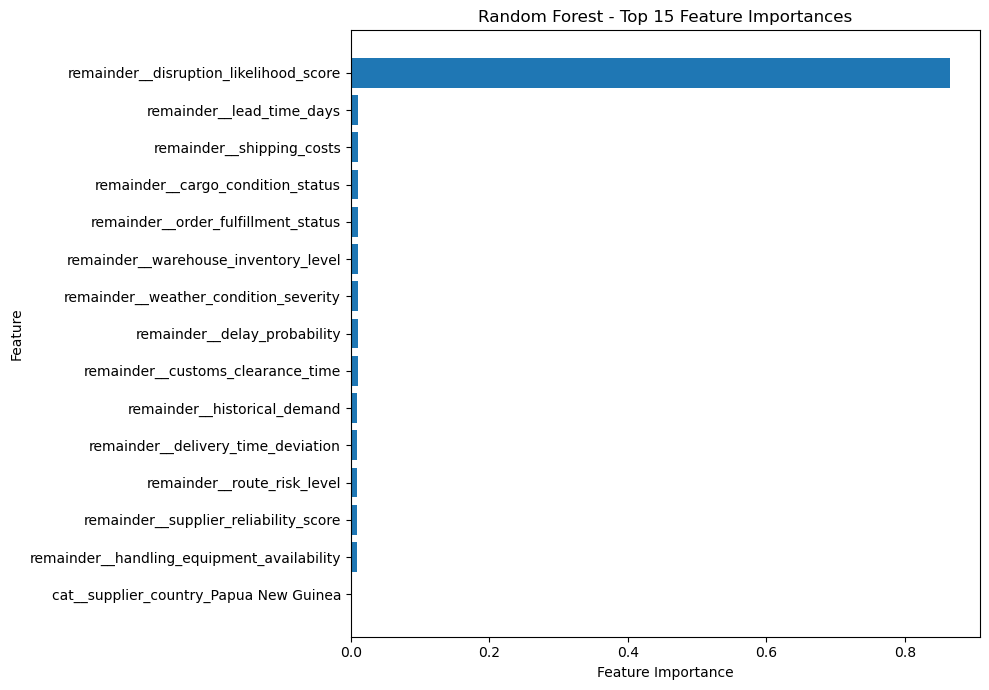

In [22]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Top 15 Feature Importances")

plt.tight_layout()
plt.show()

## 10. Verification of Target Leakage

Feature importance analysis showed that `disruption_likelihood_score` contributes approximately 86.5% of the Random Forest feature importance.

Since the Random Forest achieved 100% test accuracy, this feature may have a direct relationship with the target variable `risk_classification`.

The following analysis checks the range and distribution of disruption likelihood scores for each risk category.

In [23]:
# Detailed relationship between disruption likelihood and risk classification

leakage_check = (
    df.groupby("risk_classification")["disruption_likelihood_score"]
      .agg(["count", "min", "max", "mean", "median", "std"])
      .round(4)
)

print("=" * 75)
print("DISRUPTION LIKELIHOOD SCORE VS RISK CLASSIFICATION")
print("=" * 75)

print(leakage_check)

DISRUPTION LIKELIHOOD SCORE VS RISK CLASSIFICATION
                     count     min     max    mean  median     std
risk_classification                                               
High Risk            84368  0.7001  1.0000  0.9491  0.9903  0.0761
Low Risk             10946  0.0000  0.2998  0.1438  0.1416  0.0892
Moderate Risk        17783  0.3001  0.6999  0.5186  0.5312  0.1154


In [24]:
# Check quantiles for each risk category

quantile_check = (
    df.groupby("risk_classification")["disruption_likelihood_score"]
      .quantile([0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.0])
      .unstack()
      .round(4)
)

quantile_check.columns = [
    "Min",
    "10%",
    "25%",
    "Median",
    "75%",
    "90%",
    "Max"
]

print(quantile_check)

                        Min     10%     25%  Median     75%     90%     Max
risk_classification                                                        
High Risk            0.7001  0.8197  0.9264  0.9903  0.9997  1.0000  1.0000
Low Risk             0.0000  0.0226  0.0634  0.1416  0.2227  0.2678  0.2998
Moderate Risk        0.3001  0.3483  0.4213  0.5312  0.6195  0.6673  0.6999


## 11. Leakage-Free Model Development

To obtain a more realistic predictive model, `disruption_likelihood_score` is removed from the predictor variables.

The models are then retrained and evaluated again to determine their performance without the suspected target-leakage feature.

In [25]:
# Create leakage-free dataset

X_clean = df.drop(
    columns=[
        "risk_classification",
        "disruption_likelihood_score"
    ]
)

y_clean = df["risk_classification"]

print("Feature matrix shape:", X_clean.shape)
print("Target shape:", y_clean.shape)

print("\nRemaining Features:")
for i, column in enumerate(X_clean.columns, 1):
    print(f"{i}. {column}")

Feature matrix shape: (113097, 16)
Target shape: (113097,)

Remaining Features:
1. warehouse_inventory_level
2. handling_equipment_availability
3. order_fulfillment_status
4. weather_condition_severity
5. shipping_costs
6. supplier_reliability_score
7. lead_time_days
8. historical_demand
9. cargo_condition_status
10. route_risk_level
11. customs_clearance_time
12. delay_probability
13. delivery_time_deviation
14. product_id
15. supplier_id
16. supplier_country


In [26]:
X_clean = X_clean.drop(
    columns=["product_id", "supplier_id"],
    errors="ignore"
)

print("Final feature matrix shape:", X_clean.shape)
print("\nFinal predictive features:")

for i, column in enumerate(X_clean.columns, 1):
    print(f"{i}. {column}")

Final feature matrix shape: (113097, 14)

Final predictive features:
1. warehouse_inventory_level
2. handling_equipment_availability
3. order_fulfillment_status
4. weather_condition_severity
5. shipping_costs
6. supplier_reliability_score
7. lead_time_days
8. historical_demand
9. cargo_condition_status
10. route_risk_level
11. customs_clearance_time
12. delay_probability
13. delivery_time_deviation
14. supplier_country


## 12. Leakage-Free Train-Test Split and Preprocessing

After identifying target leakage, the `disruption_likelihood_score` feature was removed.

Identifier columns (`product_id` and `supplier_id`) were also removed because they do not represent meaningful predictive characteristics.

The remaining features are now used to build a realistic machine learning model.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Identify numerical and categorical features
numeric_features_clean = X_clean.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_clean = X_clean.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features_clean)

print("\nCategorical Features:")
print(categorical_features_clean)

print("\nNumber of Numerical Features:", len(numeric_features_clean))
print("Number of Categorical Features:", len(categorical_features_clean))

Numerical Features:
['warehouse_inventory_level', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'delay_probability', 'delivery_time_deviation']

Categorical Features:
['supplier_country']

Number of Numerical Features: 13
Number of Categorical Features: 1


In [28]:
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_clean
)

print("=" * 60)
print("LEAKAGE-FREE TRAIN-TEST SPLIT")
print("=" * 60)

print("X_train:", X_train_clean.shape)
print("X_test :", X_test_clean.shape)
print("y_train:", y_train_clean.shape)
print("y_test :", y_test_clean.shape)

print("\nTraining Target Distribution:")
print(y_train_clean.value_counts(normalize=True).round(4) * 100)

print("\nTesting Target Distribution:")
print(y_test_clean.value_counts(normalize=True).round(4) * 100)

LEAKAGE-FREE TRAIN-TEST SPLIT
X_train: (90477, 14)
X_test : (22620, 14)
y_train: (90477,)
y_test : (22620,)

Training Target Distribution:
risk_classification
High Risk        74.60
Moderate Risk    15.72
Low Risk          9.68
Name: proportion, dtype: float64

Testing Target Distribution:
risk_classification
High Risk        74.60
Moderate Risk    15.73
Low Risk          9.68
Name: proportion, dtype: float64


## 13. Leakage-Free Preprocessing Pipeline

Numerical features are standardized using StandardScaler, while categorical features are transformed using One-Hot Encoding.

The preprocessing pipeline is fitted only on the training dataset to prevent information from the test dataset from leaking into model training.

In [30]:
clean_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_clean
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features_clean
        )
    ]
)

print("Leakage-free preprocessing pipeline created successfully.")

Leakage-free preprocessing pipeline created successfully.


## 14. Leakage-Free Logistic Regression

Logistic Regression is trained as the baseline classification model after removing the target-leakage feature.

Class balancing is used because the target variable is imbalanced, with High Risk representing the majority class.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

logistic_clean_pipeline = Pipeline(
    steps=[
        ("preprocessor", clean_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_clean_pipeline.fit(
    X_train_clean,
    y_train_clean
)

logistic_clean_predictions = logistic_clean_pipeline.predict(
    X_test_clean
)

print("Leakage-Free Logistic Regression trained successfully.")

Leakage-Free Logistic Regression trained successfully.


In [32]:
logistic_clean_accuracy = accuracy_score(
    y_test_clean,
    logistic_clean_predictions
)

logistic_clean_balanced_accuracy = balanced_accuracy_score(
    y_test_clean,
    logistic_clean_predictions
)

print("=" * 70)
print("LEAKAGE-FREE LOGISTIC REGRESSION RESULTS")
print("=" * 70)

print(f"\nAccuracy          : {logistic_clean_accuracy:.4f}")
print(f"Balanced Accuracy : {logistic_clean_balanced_accuracy:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_clean,
        logistic_clean_predictions
    )
)

LEAKAGE-FREE LOGISTIC REGRESSION RESULTS

Accuracy          : 0.3035
Balanced Accuracy : 0.3488

Classification Report:

               precision    recall  f1-score   support

    High Risk       0.75      0.28      0.41     16874
     Low Risk       0.10      0.42      0.17      2189
Moderate Risk       0.16      0.35      0.22      3557

     accuracy                           0.30     22620
    macro avg       0.34      0.35      0.27     22620
 weighted avg       0.60      0.30      0.36     22620



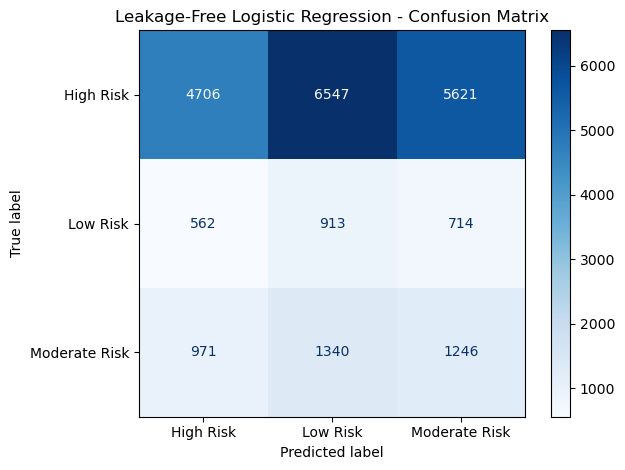

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_clean,
    logistic_clean_predictions,
    cmap="Blues",
    values_format="d"
)

plt.title("Leakage-Free Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

## 16. Leakage-Free Random Forest Model

A Random Forest classifier is now trained using the leakage-free feature set.

Random Forest can capture complex and non-linear relationships between supply-chain variables that may not be detected effectively by Logistic Regression.

Class balancing is applied to reduce the effect of the imbalanced risk-class distribution.

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_clean_pipeline = Pipeline(
    steps=[
        ("preprocessor", clean_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=10,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_clean_pipeline.fit(
    X_train_clean,
    y_train_clean
)

rf_clean_predictions = rf_clean_pipeline.predict(
    X_test_clean
)

print("Leakage-Free Random Forest trained successfully.")

Leakage-Free Random Forest trained successfully.


In [35]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

rf_clean_accuracy = accuracy_score(
    y_test_clean,
    rf_clean_predictions
)

rf_clean_balanced_accuracy = balanced_accuracy_score(
    y_test_clean,
    rf_clean_predictions
)

rf_clean_precision = precision_score(
    y_test_clean,
    rf_clean_predictions,
    average="macro"
)

rf_clean_recall = recall_score(
    y_test_clean,
    rf_clean_predictions,
    average="macro"
)

rf_clean_f1 = f1_score(
    y_test_clean,
    rf_clean_predictions,
    average="macro"
)

print("=" * 75)
print("LEAKAGE-FREE RANDOM FOREST RESULTS")
print("=" * 75)

print(f"\nAccuracy          : {rf_clean_accuracy:.4f}")
print(f"Balanced Accuracy : {rf_clean_balanced_accuracy:.4f}")
print(f"Macro Precision   : {rf_clean_precision:.4f}")
print(f"Macro Recall      : {rf_clean_recall:.4f}")
print(f"Macro F1 Score    : {rf_clean_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_clean,
        rf_clean_predictions
    )
)

LEAKAGE-FREE RANDOM FOREST RESULTS

Accuracy          : 0.7846
Balanced Accuracy : 0.6941
Macro Precision   : 0.6506
Macro Recall      : 0.6941
Macro F1 Score    : 0.6688

Classification Report:

               precision    recall  f1-score   support

    High Risk       0.88      0.84      0.86     16874
     Low Risk       0.47      0.62      0.54      2189
Moderate Risk       0.59      0.62      0.61      3557

     accuracy                           0.78     22620
    macro avg       0.65      0.69      0.67     22620
 weighted avg       0.80      0.78      0.79     22620



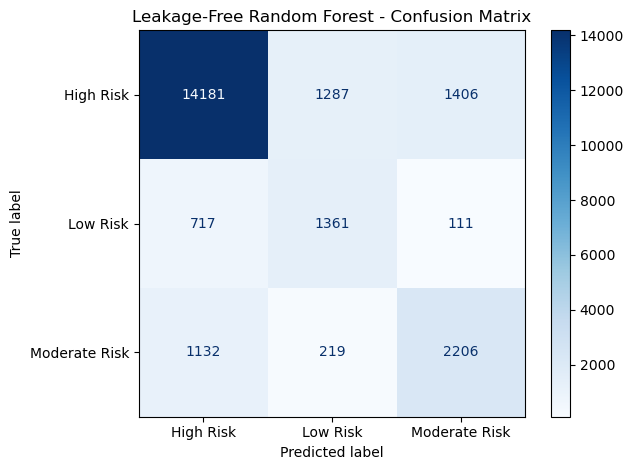

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_clean,
    rf_clean_predictions,
    cmap="Blues",
    values_format="d"
)

plt.title("Leakage-Free Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

## 19. Leakage-Free Model Comparison

The leakage-free Logistic Regression and Random Forest models are compared using multiple evaluation metrics.

Because the target classes are imbalanced, Balanced Accuracy and Macro F1 Score are considered particularly important alongside overall Accuracy.

In [37]:
comparison_clean = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    
    "Accuracy": [
        logistic_clean_accuracy,
        rf_clean_accuracy
    ],
    
    "Balanced Accuracy": [
        logistic_clean_balanced_accuracy,
        rf_clean_balanced_accuracy
    ],
    
    "Precision (Macro)": [
        precision_score(
            y_test_clean,
            logistic_clean_predictions,
            average="macro"
        ),
        rf_clean_precision
    ],
    
    "Recall (Macro)": [
        recall_score(
            y_test_clean,
            logistic_clean_predictions,
            average="macro"
        ),
        rf_clean_recall
    ],
    
    "F1 Score (Macro)": [
        f1_score(
            y_test_clean,
            logistic_clean_predictions,
            average="macro"
        ),
        rf_clean_f1
    ]
})

comparison_clean = comparison_clean.round(4)

comparison_clean

,Model,Accuracy,Balanced Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
0,Logistic Regression,0.3035,0.3488,0.3408,0.3488,0.2657
1,Random Forest,0.7846,0.6941,0.6506,0.6941,0.6688


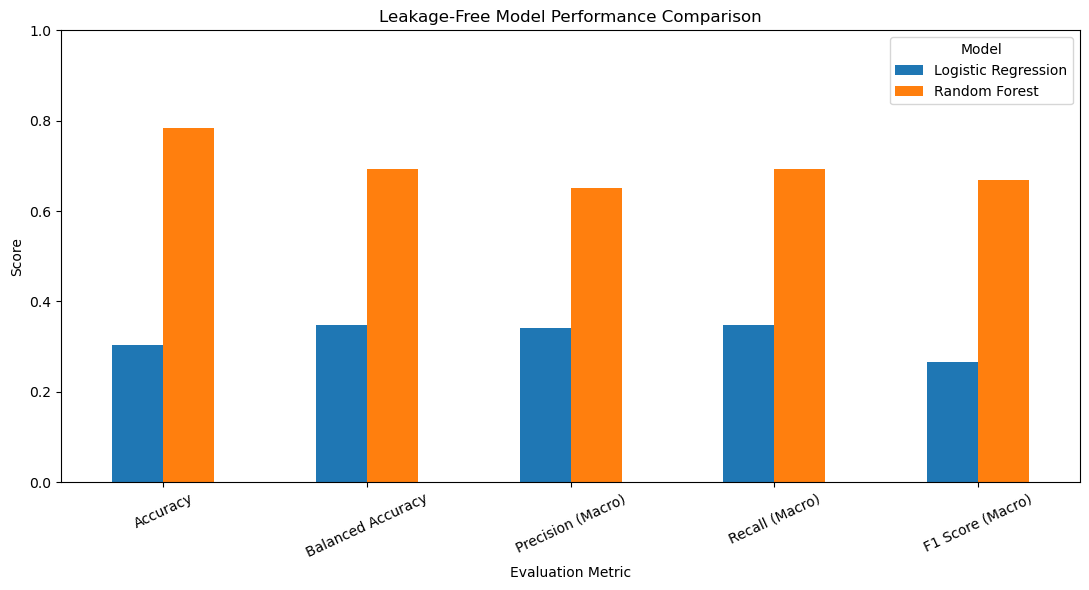

In [38]:
comparison_plot = comparison_clean.set_index("Model")

comparison_plot[
    [
        "Accuracy",
        "Balanced Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1 Score (Macro)"
    ]
].T.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Leakage-Free Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)

plt.xticks(rotation=25)
plt.legend(title="Model")

plt.tight_layout()
plt.show()

## 21. Leakage-Free Random Forest Feature Importance

Feature importance is analyzed for the final Random Forest model to identify the operational variables that contribute most strongly to supply-chain risk prediction.

Unlike the earlier model, the target-leakage feature `disruption_likelihood_score` has been removed.

In [39]:
# Get fitted preprocessor and Random Forest
fitted_preprocessor = rf_clean_pipeline.named_steps["preprocessor"]
fitted_rf = rf_clean_pipeline.named_steps["classifier"]

# Get transformed feature names
feature_names_clean = fitted_preprocessor.get_feature_names_out()

# Extract feature importances
rf_clean_importance = pd.DataFrame({
    "Feature": feature_names_clean,
    "Importance": fitted_rf.feature_importances_
})

rf_clean_importance = (
    rf_clean_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("=" * 75)
print("TOP 20 LEAKAGE-FREE RANDOM FOREST FEATURES")
print("=" * 75)

print(rf_clean_importance.head(20))

TOP 20 LEAKAGE-FREE RANDOM FOREST FEATURES
                                      Feature  Importance
0                         num__lead_time_days    0.079558
1                 num__cargo_condition_status    0.077618
2                      num__delay_probability    0.075664
3                         num__shipping_costs    0.073842
4               num__order_fulfillment_status    0.073716
5                       num__route_risk_level    0.073525
6              num__warehouse_inventory_level    0.073111
7                 num__customs_clearance_time    0.072716
8                      num__historical_demand    0.072463
9             num__weather_condition_severity    0.072433
10               num__delivery_time_deviation    0.069941
11       num__handling_equipment_availability    0.069651
12            num__supplier_reliability_score    0.068682
13     cat__supplier_country_Papua New Guinea    0.001255
14                cat__supplier_country_Ghana    0.001003
15          cat__supplier_cou

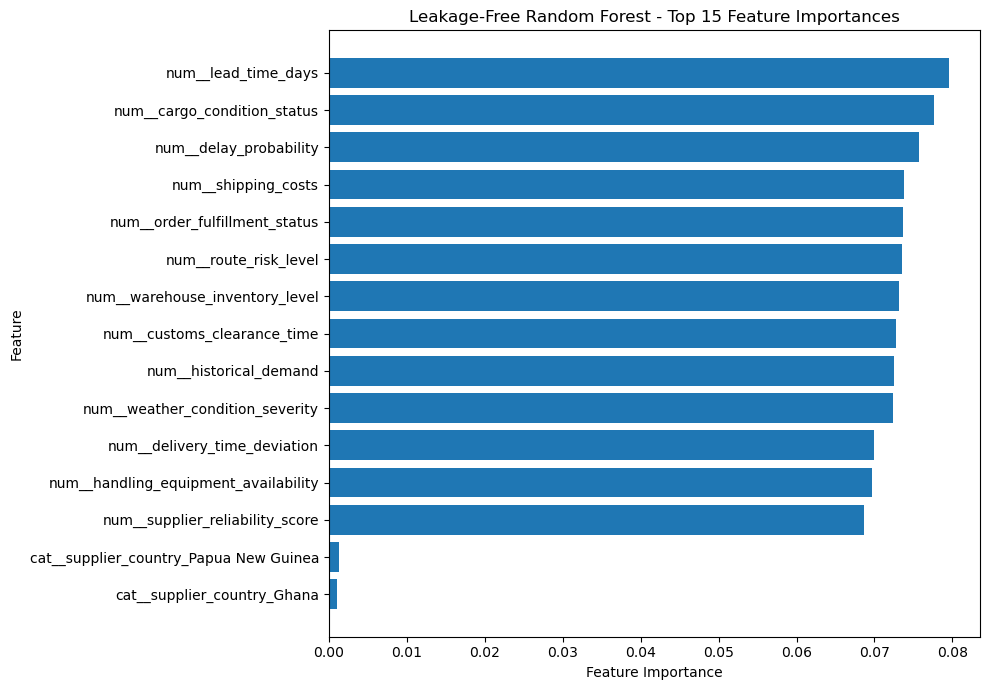

In [40]:
top_features_clean = rf_clean_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features_clean["Feature"],
    top_features_clean["Importance"]
)

plt.title("Leakage-Free Random Forest - Top 15 Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 22. Pre-Decision Feature Validation

The purpose of Supply-Prescript is to predict disruption risk early enough for the
prescriptive optimization module to recommend preventive supply-chain actions.

Therefore, features that may only become available after shipment execution or
during the realization of a disruption are treated cautiously.

A stricter pre-decision feature set is evaluated to determine whether the model
can predict risk using information realistically available at decision time.

In [41]:
# Review current model features according to when they become available

feature_timing = pd.DataFrame({
    "Feature": X_clean.columns,
    "Timing_Category": [
        "Pre-decision",      # warehouse_inventory_level
        "Pre-decision",      # handling_equipment_availability
        "Potentially late",  # order_fulfillment_status
        "Pre-decision",      # weather_condition_severity
        "Pre-decision",      # shipping_costs
        "Pre-decision",      # supplier_reliability_score
        "Pre-decision",      # lead_time_days
        "Pre-decision",      # historical_demand
        "Potentially late",  # cargo_condition_status
        "Pre-decision",      # route_risk_level
        "Pre-decision",      # customs_clearance_time
        "Potentially late",  # delay_probability
        "Potentially late",  # delivery_time_deviation
        "Pre-decision"       # supplier_country
    ]
})

feature_timing

,Feature,Timing_Category
0,warehouse_inventory_level,Pre-decision
1,handling_equipment_availability,Pre-decision
2,order_fulfillment_status,Potentially late
3,weather_condition_severity,Pre-decision
4,shipping_costs,Pre-decision
5,supplier_reliability_score,Pre-decision
6,lead_time_days,Pre-decision
7,historical_demand,Pre-decision
8,cargo_condition_status,Potentially late
9,route_risk_level,Pre-decision


In [42]:
potential_post_decision_features = [
    "order_fulfillment_status",
    "cargo_condition_status",
    "delay_probability",
    "delivery_time_deviation"
]

X_predecision = X_clean.drop(
    columns=potential_post_decision_features,
    errors="ignore"
)

print("=" * 70)
print("STRICT PRE-DECISION FEATURE SET")
print("=" * 70)

print("Original features :", X_clean.shape[1])
print("Remaining features:", X_predecision.shape[1])

print("\nFeatures used:")
for i, feature in enumerate(X_predecision.columns, 1):
    print(f"{i}. {feature}")

STRICT PRE-DECISION FEATURE SET
Original features : 14
Remaining features: 10

Features used:
1. warehouse_inventory_level
2. handling_equipment_availability
3. weather_condition_severity
4. shipping_costs
5. supplier_reliability_score
6. lead_time_days
7. historical_demand
8. route_risk_level
9. customs_clearance_time
10. supplier_country


In [43]:
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_predecision,
    y_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_clean
)

print("X_train:", X_train_pre.shape)
print("X_test :", X_test_pre.shape)
print("y_train:", y_train_pre.shape)
print("y_test :", y_test_pre.shape)

X_train: (90477, 10)
X_test : (22620, 10)
y_train: (90477,)
y_test : (22620,)


In [44]:
numeric_features_pre = X_predecision.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features_pre = X_predecision.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features_pre)

print("\nCategorical Features:")
print(categorical_features_pre)

Numerical Features:
['warehouse_inventory_level', 'handling_equipment_availability', 'weather_condition_severity', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'route_risk_level', 'customs_clearance_time']

Categorical Features:
['supplier_country']


In [45]:
preprocessor_pre = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_pre
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_pre
        )
    ]
)

print("Pre-decision preprocessing pipeline created.")

Pre-decision preprocessing pipeline created.


In [46]:
rf_predecision_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_pre),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

rf_predecision_pipeline.fit(
    X_train_pre,
    y_train_pre
)

rf_pre_predictions = rf_predecision_pipeline.predict(
    X_test_pre
)

print("Strict pre-decision Random Forest trained successfully.")

Strict pre-decision Random Forest trained successfully.


In [47]:
pre_accuracy = accuracy_score(
    y_test_pre,
    rf_pre_predictions
)

pre_balanced_accuracy = balanced_accuracy_score(
    y_test_pre,
    rf_pre_predictions
)

pre_precision = precision_score(
    y_test_pre,
    rf_pre_predictions,
    average="macro"
)

pre_recall = recall_score(
    y_test_pre,
    rf_pre_predictions,
    average="macro"
)

pre_f1 = f1_score(
    y_test_pre,
    rf_pre_predictions,
    average="macro"
)

print("=" * 70)
print("STRICT PRE-DECISION RANDOM FOREST RESULTS")
print("=" * 70)

print(f"Accuracy          : {pre_accuracy:.4f}")
print(f"Balanced Accuracy : {pre_balanced_accuracy:.4f}")
print(f"Macro Precision   : {pre_precision:.4f}")
print(f"Macro Recall      : {pre_recall:.4f}")
print(f"Macro F1 Score    : {pre_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_pre,
        rf_pre_predictions
    )
)

STRICT PRE-DECISION RANDOM FOREST RESULTS
Accuracy          : 0.9439
Balanced Accuracy : 0.8480
Macro Precision   : 0.9767
Macro Recall      : 0.8480
Macro F1 Score    : 0.9019

Classification Report:

               precision    recall  f1-score   support

    High Risk       0.93      1.00      0.96     16874
     Low Risk       1.00      0.74      0.85      2189
Moderate Risk       1.00      0.80      0.89      3557

     accuracy                           0.94     22620
    macro avg       0.98      0.85      0.90     22620
 weighted avg       0.95      0.94      0.94     22620



## 27. Target Leakage Investigation

The strict pre-decision Random Forest achieved unexpectedly high predictive
performance after removing four potentially post-decision variables.

Before selecting the final model, the relationship between the target variable
and the remaining predictors is investigated to ensure that Risk_Level is not
directly derived from one or more model inputs.

In [48]:
print("=" * 70)
print("TARGET VARIABLE INFORMATION")
print("=" * 70)

print("\nTarget:")
print(y_clean.name)

print("\nTarget distribution:")
print(y_clean.value_counts())

print("\nTarget percentages:")
print((y_clean.value_counts(normalize=True) * 100).round(2))

TARGET VARIABLE INFORMATION

Target:
risk_classification

Target distribution:
risk_classification
High Risk        84368
Moderate Risk    17783
Low Risk         10946
Name: count, dtype: int64

Target percentages:
risk_classification
High Risk        74.60
Moderate Risk    15.72
Low Risk          9.68
Name: proportion, dtype: float64


In [49]:
analysis_df = X_predecision.copy()
analysis_df["Risk_Level"] = y_clean.values

numeric_summary = (
    analysis_df
    .groupby("Risk_Level")[numeric_features_pre]
    .mean()
    .round(3)
    .T
)

print("=" * 70)
print("MEAN FEATURE VALUES BY RISK CLASS")
print("=" * 70)

numeric_summary

MEAN FEATURE VALUES BY RISK CLASS


Risk_Level,High Risk,Low Risk,Moderate Risk
warehouse_inventory_level,298.667,313.493,300.426
handling_equipment_availability,0.305,0.301,0.299
weather_condition_severity,0.498,0.503,0.495
shipping_costs,459.176,461.561,461.016
supplier_reliability_score,0.501,0.503,0.498
lead_time_days,5.240,5.268,5.073
historical_demand,6016.723,6008.599,6042.109
route_risk_level,7.008,6.934,6.979
customs_clearance_time,2.298,2.304,2.284


In [50]:
from sklearn.metrics import balanced_accuracy_score

single_feature_results = []

for feature in numeric_features_pre:

    X_single = X_predecision[[feature]]

    X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
        X_single,
        y_clean,
        test_size=0.20,
        random_state=42,
        stratify=y_clean
    )

    model_single = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        max_depth=8
    )

    model_single.fit(X_train_single, y_train_single)

    pred_single = model_single.predict(X_test_single)

    single_feature_results.append({
        "Feature": feature,
        "Accuracy": accuracy_score(y_test_single, pred_single),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_test_single,
            pred_single
        )
    })

single_feature_results_df = pd.DataFrame(
    single_feature_results
).sort_values(
    "Balanced_Accuracy",
    ascending=False
)

single_feature_results_df.round(4)

,Feature,Accuracy,Balanced_Accuracy
4,supplier_reliability_score,0.4031,0.4690
6,historical_demand,0.3441,0.4427
0,warehouse_inventory_level,0.4543,0.4382
1,handling_equipment_availability,0.4002,0.4365
3,shipping_costs,0.5598,0.4328
7,route_risk_level,0.5337,0.4315
5,lead_time_days,0.3779,0.4173
2,weather_condition_severity,0.3046,0.4151
8,customs_clearance_time,0.4588,0.4149


In [51]:
preprocessor_fitted = rf_predecision_pipeline.named_steps["preprocessor"]
rf_fitted = rf_predecision_pipeline.named_steps["classifier"]

feature_names_pre = preprocessor_fitted.get_feature_names_out()

pre_feature_importance = pd.DataFrame({
    "Feature": feature_names_pre,
    "Importance": rf_fitted.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("=" * 70)
print("STRICT PRE-DECISION RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

print(
    pre_feature_importance
    .head(20)
    .to_string(index=False)
)

STRICT PRE-DECISION RANDOM FOREST FEATURE IMPORTANCE
                                  Feature  Importance
                      num__lead_time_days    0.096918
              num__customs_clearance_time    0.096569
                      num__shipping_costs    0.096492
          num__supplier_reliability_score    0.096326
           num__warehouse_inventory_level    0.096194
          num__weather_condition_severity    0.095915
                    num__route_risk_level    0.095911
                   num__historical_demand    0.095900
     num__handling_equipment_availability    0.094983
            cat__supplier_country_Vietnam    0.002024
        cat__supplier_country_Philippines    0.001858
         cat__supplier_country_Kyrgyzstan    0.001842
            cat__supplier_country_Georgia    0.001838
cat__supplier_country_Trinidad and Tobago    0.001834
           cat__supplier_country_Colombia    0.001817
            cat__supplier_country_Romania    0.001804
           cat__supplier_coun

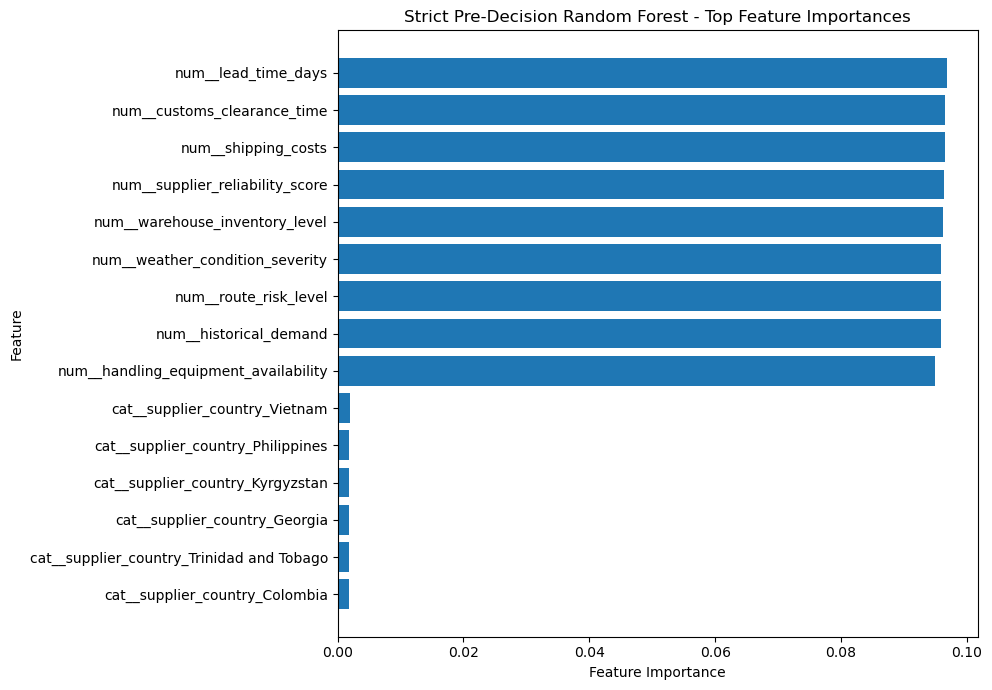

In [52]:
top_pre_features = (
    pre_feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_pre_features["Feature"],
    top_pre_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Strict Pre-Decision Random Forest - Top Feature Importances"
)

plt.tight_layout()
plt.show()

## 31. Cross-Validation of the Final Predictive Model

To verify that the strong performance of the strict pre-decision Random Forest
is not dependent on a single train-test split, stratified cross-validation is
performed.

Balanced accuracy is used as the primary validation metric because the target
classes are imbalanced.

In [53]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro"
}

cv_results = cross_validate(
    rf_predecision_pipeline,
    X_predecision,
    y_clean,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("=" * 70)
print("5-FOLD STRATIFIED CROSS-VALIDATION RESULTS")
print("=" * 70)

for i in range(5):
    print(
        f"Fold {i+1}: "
        f"Accuracy = {cv_results['test_accuracy'][i]:.4f} | "
        f"Balanced Accuracy = "
        f"{cv_results['test_balanced_accuracy'][i]:.4f} | "
        f"Macro F1 = {cv_results['test_f1_macro'][i]:.4f}"
    )

print("\n" + "=" * 70)
print("AVERAGE CROSS-VALIDATION PERFORMANCE")
print("=" * 70)

print(
    f"Mean Accuracy          : "
    f"{cv_results['test_accuracy'].mean():.4f}"
)

print(
    f"Mean Balanced Accuracy : "
    f"{cv_results['test_balanced_accuracy'].mean():.4f}"
)

print(
    f"Mean Macro F1          : "
    f"{cv_results['test_f1_macro'].mean():.4f}"
)

print(
    f"Accuracy Std           : "
    f"{cv_results['test_accuracy'].std():.4f}"
)

print(
    f"Balanced Accuracy Std  : "
    f"{cv_results['test_balanced_accuracy'].std():.4f}"
)

print(
    f"Macro F1 Std           : "
    f"{cv_results['test_f1_macro'].std():.4f}"
)

5-FOLD STRATIFIED CROSS-VALIDATION RESULTS
Fold 1: Accuracy = 0.9448 | Balanced Accuracy = 0.8526 | Macro F1 = 0.9052
Fold 2: Accuracy = 0.9448 | Balanced Accuracy = 0.8520 | Macro F1 = 0.9048
Fold 3: Accuracy = 0.9456 | Balanced Accuracy = 0.8513 | Macro F1 = 0.9042
Fold 4: Accuracy = 0.9481 | Balanced Accuracy = 0.8612 | Macro F1 = 0.9112
Fold 5: Accuracy = 0.9405 | Balanced Accuracy = 0.8416 | Macro F1 = 0.8973

AVERAGE CROSS-VALIDATION PERFORMANCE
Mean Accuracy          : 0.9448
Mean Balanced Accuracy : 0.8517
Mean Macro F1          : 0.9045
Accuracy Std           : 0.0025
Balanced Accuracy Std  : 0.0062
Macro F1 Std           : 0.0044


## 32. Final Model Selection

After evaluating multiple predictive approaches, investigating potential target
leakage, restricting the feature set to variables available before operational
decision-making, and performing stratified 5-fold cross-validation, the
Random Forest classifier was selected as the final predictive model.

### Final Holdout Performance

- Accuracy: **94.39%**
- Balanced Accuracy: **84.80%**
- Macro Precision: **97.67%**
- Macro Recall: **84.80%**
- Macro F1 Score: **90.19%**

### 5-Fold Cross-Validation Performance

- Mean Accuracy: **94.48%**
- Mean Balanced Accuracy: **85.17%**
- Mean Macro F1 Score: **90.45%**

The low standard deviation across the five folds indicates that the model
performance is stable across different subsets of the dataset.

The final model uses only strict pre-decision features to reduce the risk of
target leakage and to make the model suitable for real-world supply-chain
risk prediction.

The Random Forest model will therefore be used as the predictive component
of the Supply-Prescript prescriptive analytics system.

## 33. Train Final Production Model

After model evaluation and cross-validation, the selected Random Forest
pipeline is retrained using the complete available dataset.

This allows the final production model to learn from all available historical
observations before being saved for use by the prescriptive optimization
module.

In [54]:
from sklearn.base import clone

final_rf_model = clone(rf_predecision_pipeline)

final_rf_model.fit(
    X_predecision,
    y_clean
)

print("=" * 70)
print("FINAL PRODUCTION MODEL")
print("=" * 70)

print("Algorithm          : Random Forest Classifier")
print("Training records   :", len(X_predecision))
print("Number of features :", X_predecision.shape[1])
print("Target             : risk_classification")
print("Status             : Trained successfully")

FINAL PRODUCTION MODEL
Algorithm          : Random Forest Classifier
Training records   : 113097
Number of features : 10
Target             : risk_classification
Status             : Trained successfully


## 34. Save Final Predictive Model

The trained Random Forest pipeline is saved for future use in the
prescriptive analytics system. The saved pipeline contains both the
preprocessing transformations and the trained classifier, ensuring that
new supply-chain records are processed in exactly the same way as the
training data.

In [55]:
import joblib
from pathlib import Path

# Create models directory if it does not already exist
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# Final model path
model_path = models_dir / "supply_chain_risk_model.pkl"

# Save complete preprocessing + Random Forest pipeline
joblib.dump(final_rf_model, model_path)

print("=" * 70)
print("FINAL MODEL SAVED SUCCESSFULLY")
print("=" * 70)
print("Model name :", model_path.name)
print("Location   :", model_path)
print("Algorithm  : Random Forest Classifier")
print("Features   :", X_predecision.shape[1])
print("Status     : Ready for deployment")

FINAL MODEL SAVED SUCCESSFULLY
Model name : supply_chain_risk_model.pkl
Location   : ..\models\supply_chain_risk_model.pkl
Algorithm  : Random Forest Classifier
Features   : 10
Status     : Ready for deployment


## 35. Create Model Metadata

Model metadata is stored along with the trained predictive model.
It records important information such as the algorithm, target variable,
input features, training size, validation performance, and model file.
This improves reproducibility, documentation, and deployment readiness.

In [57]:
import json
from datetime import datetime
from pathlib import Path

# ---------------------------------------------------------
# Detect the Macro F1 key used in cross-validation results
# ---------------------------------------------------------
if "test_macro_f1" in cv_results:
    macro_f1_key = "test_macro_f1"
elif "test_f1_macro" in cv_results:
    macro_f1_key = "test_f1_macro"
else:
    macro_f1_key = None


# ---------------------------------------------------------
# Create model metadata
# ---------------------------------------------------------
model_metadata = {
    "model_name": "Supply Chain Risk Prediction Model",
    "model_file": "supply_chain_risk_model.pkl",
    "algorithm": "Random Forest Classifier",

    "target_variable": "risk_classification",

    "training_records": int(len(X_predecision)),
    "number_of_features": int(X_predecision.shape[1]),

    "input_features": X_predecision.columns.tolist(),

    "risk_classes": sorted(
        y_clean.astype(str).unique().tolist()
    ),

    "validation": {
        "method": "5-Fold Stratified Cross-Validation",

        "mean_accuracy": round(
            float(cv_results["test_accuracy"].mean()), 4
        ),

        "mean_balanced_accuracy": round(
            float(cv_results["test_balanced_accuracy"].mean()), 4
        ),

        "mean_macro_f1": (
            round(float(cv_results[macro_f1_key].mean()), 4)
            if macro_f1_key is not None
            else None
        )
    },

    "model_type": "Pre-decision predictive model",

    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "status": "Production Ready"
}


# ---------------------------------------------------------
# Save metadata
# ---------------------------------------------------------
metadata_path = Path("../models/model_metadata.json")

with open(metadata_path, "w") as file:
    json.dump(model_metadata, file, indent=4)


# ---------------------------------------------------------
# Display metadata summary
# ---------------------------------------------------------
print("=" * 70)
print("MODEL METADATA SAVED SUCCESSFULLY")
print("=" * 70)

print("Metadata file       :", metadata_path.name)
print("Algorithm           :", model_metadata["algorithm"])
print("Target              :", model_metadata["target_variable"])
print("Training records    :", model_metadata["training_records"])
print("Number of features  :", model_metadata["number_of_features"])
print("Risk classes        :", model_metadata["risk_classes"])

print("\nCross-Validation Performance")
print("-" * 40)

print(
    "Mean Accuracy          :",
    model_metadata["validation"]["mean_accuracy"]
)

print(
    "Mean Balanced Accuracy :",
    model_metadata["validation"]["mean_balanced_accuracy"]
)

print(
    "Mean Macro F1          :",
    model_metadata["validation"]["mean_macro_f1"]
)

print("\nStatus :", model_metadata["status"])

print("\nMetadata saved at:")
print(metadata_path)

MODEL METADATA SAVED SUCCESSFULLY
Metadata file       : model_metadata.json
Algorithm           : Random Forest Classifier
Target              : risk_classification
Training records    : 113097
Number of features  : 10
Risk classes        : ['High Risk', 'Low Risk', 'Moderate Risk']

Cross-Validation Performance
----------------------------------------
Mean Accuracy          : 0.9448
Mean Balanced Accuracy : 0.8517
Mean Macro F1          : 0.9045

Status : Production Ready

Metadata saved at:
..\models\model_metadata.json


## 36. Load and Verify Saved Predictive Model

The saved production model is loaded from disk and tested to ensure that
serialization was successful. Sample records are passed through the complete
pipeline to verify that the model can generate risk predictions after loading.

In [58]:
import joblib
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# Load saved production model
# ---------------------------------------------------------
model_path = Path("../models/supply_chain_risk_model.pkl")

loaded_model = joblib.load(model_path)

print("=" * 70)
print("SAVED MODEL LOADED SUCCESSFULLY")
print("=" * 70)

print("Model file :", model_path.name)
print("Model type :", type(loaded_model).__name__)


# ---------------------------------------------------------
# Select sample records
# ---------------------------------------------------------
sample_data = X_predecision.head(10).copy()
sample_actual = y_clean.head(10).copy()


# ---------------------------------------------------------
# Generate predictions
# ---------------------------------------------------------
sample_predictions = loaded_model.predict(sample_data)


# ---------------------------------------------------------
# Generate prediction probabilities
# ---------------------------------------------------------
sample_probabilities = loaded_model.predict_proba(sample_data)

classes = loaded_model.named_steps["classifier"].classes_

confidence_scores = sample_probabilities.max(axis=1)


# ---------------------------------------------------------
# Create verification table
# ---------------------------------------------------------
verification_results = pd.DataFrame({
    "Actual_Risk": sample_actual.values,
    "Predicted_Risk": sample_predictions,
    "Confidence": confidence_scores
})

verification_results["Correct"] = (
    verification_results["Actual_Risk"]
    == verification_results["Predicted_Risk"]
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------
print("\nSample Prediction Verification")
print("-" * 70)

display(verification_results)


# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------
correct_predictions = verification_results["Correct"].sum()

print("\n" + "=" * 70)
print("MODEL VERIFICATION SUMMARY")
print("=" * 70)

print("Records tested       :", len(verification_results))
print("Correct predictions  :", correct_predictions)
print(
    "Verification accuracy:",
    round(correct_predictions / len(verification_results), 4)
)

print(
    "Average confidence   :",
    round(verification_results["Confidence"].mean(), 4)
)

print("\nModel classes:")
print(classes)

print("\nStatus: SAVED MODEL IS WORKING SUCCESSFULLY")

SAVED MODEL LOADED SUCCESSFULLY
Model file : supply_chain_risk_model.pkl
Model type : Pipeline

Sample Prediction Verification
----------------------------------------------------------------------


,Actual_Risk,Predicted_Risk,Confidence,Correct
0,Moderate Risk,Moderate Risk,0.860000,True
1,Moderate Risk,Moderate Risk,0.883333,True
2,Moderate Risk,Moderate Risk,0.890000,True
3,High Risk,High Risk,0.953333,True
4,High Risk,High Risk,0.966667,True
5,High Risk,High Risk,0.940000,True
6,High Risk,High Risk,0.960000,True
7,High Risk,High Risk,0.956667,True
8,High Risk,High Risk,0.986667,True
9,High Risk,High Risk,0.973333,True



MODEL VERIFICATION SUMMARY
Records tested       : 10
Correct predictions  : 10
Verification accuracy: 1.0
Average confidence   : 0.937

Model classes:
['High Risk' 'Low Risk' 'Moderate Risk']

Status: SAVED MODEL IS WORKING SUCCESSFULLY
